# Multi-Depot VRPTW sobre red vial simulada (OSRM) y polígonos reales

Extiende el motor de ruteo de Fase 1 (1 depósito, distancia en línea recta) a **múltiples depósitos** resueltos conjuntamente por OR-Tools, sobre una **matriz de distancias por red vial simulada** (factor de circuidad sobre Haversine vectorizado) y demanda generada dentro de **polígonos reales** de comuna (no círculos aproximados).

Todo lo que sigue corre de verdad -- nada está precalculado.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from src.spatial.comunas import load_target_comunas
from src.spatial.geo_generator import assign_h3_index, aggregate_by_h3, generate_demand_within_polygons, select_dark_store_candidates
from src.spatial.network_distance import benchmark_haversine_speedup
from src.optimization.multi_depot_vrp import build_multi_depot_instance, solve_multi_depot_vrp, summarize_by_depot
from src.spatial.map_export import export_folium_map, export_pydeck_map

%matplotlib inline
pd.options.display.float_format = "{:.2f}".format

## 1. Demanda dentro de polígonos reales de comuna

`load_target_comunas()` carga los límites administrativos reales (no círculos) de Las Condes, Providencia, Santiago Centro, Maipú y San Bernardo -- ver `src/spatial/comunas.py` para la fuente de datos. `generate_demand_within_polygons` hace rejection sampling dentro de cada polígono real, así que todo punto generado está garantizado de caer dentro del límite comunal real.

In [2]:
comunas = load_target_comunas()
gdf = assign_h3_index(generate_demand_within_polygons(comunas, n_per_comuna=45, seed=42))
h3_agg = aggregate_by_h3(gdf)

print(f"Pedidos generados: {len(gdf)}")
print(f"Celdas H3 con demanda: {len(h3_agg)}")
print(f"Demanda total: {int(h3_agg['total_demand'].sum())} unidades")
comunas[["comuna"]]

Pedidos generados: 225
Celdas H3 con demanda: 173
Demanda total: 1025 unidades


,comuna
0,Providencia
1,Santiago Centro
2,San Bernardo
3,Las Condes
4,Maipú


## 2. Selección de 3 depósitos (Dark Stores) candidatos

Reutiliza `select_dark_store_candidates` (Fase 1): las celdas H3 con mayor demanda agregada, ahora usadas como depósitos *simultáneos*, no uno a la vez.

In [3]:
N_DEPOTS = 3
candidates = select_dark_store_candidates(h3_agg, n_stores=N_DEPOTS)
depots = list(zip(candidates["centroid_lat"], candidates["centroid_lon"]))
depot_labels = [f"{row.comuna} (demanda {row.total_demand})" for row in candidates.itertuples()]

demand_cells = h3_agg[~h3_agg["h3_cell"].isin(candidates["h3_cell"])].reset_index(drop=True)

print("Depósitos seleccionados:")
for label in depot_labels:
    print(f"  - {label}")
print(f"\nCeldas de demanda a rutear (excluyendo depósitos): {len(demand_cells)}")

Depósitos seleccionados:
  - Providencia (demanda 29)
  - Santiago Centro (demanda 24)
  - Santiago Centro (demanda 15)

Celdas de demanda a rutear (excluyendo depósitos): 170


## 3. Matriz de distancias: Haversine vectorizada vs. red vial simulada

`benchmark_haversine_speedup` mide el speedup real de la versión vectorizada con NumPy contra el doble loop en Python puro de `vrp_solver.py` (Fase 1), sobre el mismo conjunto de puntos.

In [4]:
all_locations = depots + list(zip(demand_cells["centroid_lat"], demand_cells["centroid_lon"]))
benchmark = benchmark_haversine_speedup(all_locations)
print(f"n ubicaciones: {benchmark['n_locations']}")
print(f"Loop puro (Python): {benchmark['loop_seconds']*1000:.2f} ms")
print(f"Vectorizado (NumPy): {benchmark['vectorized_seconds']*1000:.2f} ms")
print(f"Speedup medido: {benchmark['speedup_x']:.1f}x")

n ubicaciones: 173
Loop puro (Python): 43.49 ms
Vectorizado (NumPy): 1.51 ms
Speedup medido: 28.7x


## 4. Construir y resolver el Multi-Depot VRPTW

`build_multi_depot_instance` arma la matriz de distancias por red vial simulada internamente (factor de circuidad por par, mayor si cruza de comuna). `solve_multi_depot_vrp` usa `starts`/`ends` nativos de OR-Tools -- el solver decide conjuntamente qué vehículo, de qué depósito, atiende cada celda.

In [5]:
VEHICLES_PER_DEPOT = [3, 3, 3]
VEHICLE_CAPACITY = 150

instance = build_multi_depot_instance(
    demand_cells, depots, vehicles_per_depot=VEHICLES_PER_DEPOT, vehicle_capacity=VEHICLE_CAPACITY,
)
solution = solve_multi_depot_vrp(instance, time_limit_seconds=30)

if solution is None:
    print("No se encontró una solución factible.")
else:
    print(f"Distancia total (red simulada): {solution.total_distance_km:.2f} km")
    print(f"Vehículos utilizados: {len(solution.routes)} / {instance.num_vehicles}")
    print(f"Celdas sin asignar: {len(solution.dropped)}")

Distancia total (red simulada): 503.90 km
Vehículos utilizados: 8 / 9
Celdas sin asignar: 0


## 5. Balance de carga por depósito

In [6]:
depot_summary = pd.DataFrame(summarize_by_depot(solution, instance.depot_indices, depot_labels))
depot_summary

,depot_index,depot_label,n_vehicles_used,total_distance_km,total_load,n_stops
0,0,Providencia (demanda 29),3,124.73,394,63
1,1,Santiago Centro (demanda 24),2,153.22,299,60
2,2,Santiago Centro (demanda 15),3,225.95,264,47


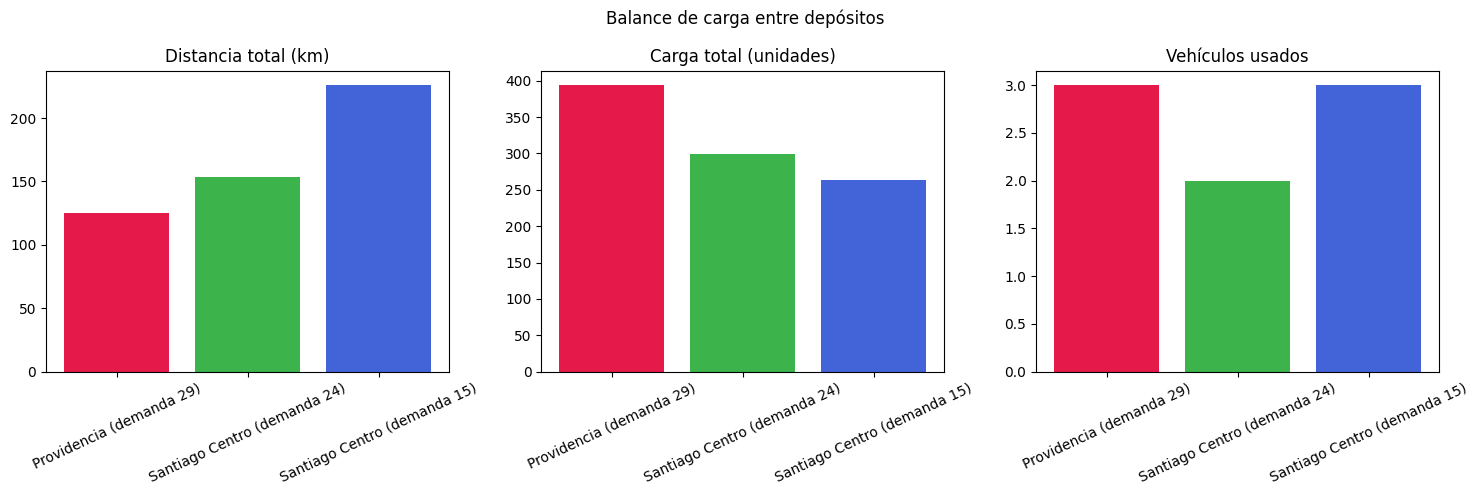

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = [("total_distance_km", "Distancia total (km)"), ("total_load", "Carga total (unidades)"), ("n_vehicles_used", "Vehículos usados")]
colors = ["#e6194b", "#3cb44b", "#4363d8"]

for ax, (col, title) in zip(axes, metrics):
    ax.bar(depot_summary["depot_label"], depot_summary[col], color=colors)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=25)

fig.suptitle("Balance de carga entre depósitos")
fig.tight_layout()
plt.show()

**Lectura**: la asignación conjunta que hace OR-Tools no reparte la demanda en partes iguales entre depósitos -- reparte según qué asignación minimiza la distancia total recorrida sujeta a las capacidades. Un depósito con celdas de demanda cercanas y densas puede terminar con más carga y menos distancia que uno cuyas celdas asignadas están más dispersas, lo cual es exactamente la señal que un planificador de flota necesita: no solo *cuánta* demanda cae cerca de cada depósito, sino *cuánto cuesta* atenderla.

## 6. Mapas interactivos exportados

Un mapa Folium (2D, con la demanda por celda H3 de fondo) y un mapa Pydeck (arcos 3D coloreados por depósito) -- ambos coloreando cada ruta según su depósito de origen.

In [8]:
folium_path = export_folium_map(
    h3_agg, depots, depot_labels, solution, instance.locations,
    "outputs/maps/multidepot_folium.html",
)
pydeck_path = export_pydeck_map(
    depots, depot_labels, solution, instance.locations,
    "outputs/maps/multidepot_pydeck.html",
)
print(f"Mapa Folium guardado en: {folium_path}")
print(f"Mapa Pydeck guardado en: {pydeck_path}")

Mapa Folium guardado en: outputs\maps\multidepot_folium.html
Mapa Pydeck guardado en: outputs\maps\multidepot_pydeck.html


In [9]:
import folium

# Re-renderiza el mismo mapa Folium directamente en el notebook (ademas del
# HTML standalone guardado arriba), reusando la misma funcion de exportacion
# para no duplicar la logica de dibujo.
from src.spatial.map_export import DEPOT_COLORS_HEX, depot_color_index

center = (sum(d[0] for d in depots) / len(depots), sum(d[1] for d in depots) / len(depots))
fmap = folium.Map(location=center, zoom_start=11, tiles="cartodbpositron")

vmin, vmax = h3_agg["total_demand"].min(), h3_agg["total_demand"].max()
for _, row in h3_agg.iterrows():
    boundary = [(lat, lon) for lon, lat in row["geometry"].exterior.coords]
    ratio = 0.0 if vmax == vmin else (row["total_demand"] - vmin) / (vmax - vmin)
    fill = f"#{255:02x}{int(255 * (1 - ratio)):02x}{60:02x}"
    folium.Polygon(locations=boundary, color="#333333", weight=1, fill=True, fill_color=fill, fill_opacity=0.5).add_to(fmap)

for depot_idx, (depot, label) in enumerate(zip(depots, depot_labels)):
    color_hex = DEPOT_COLORS_HEX[depot_color_index(depot_idx, instance.depot_indices)]
    folium.Marker(location=depot, popup=label, icon=folium.Icon(color="black", icon="home", prefix="fa")).add_to(fmap)

for route in solution.routes:
    color_hex = DEPOT_COLORS_HEX[depot_color_index(route.depot_index, instance.depot_indices)]
    points = [instance.locations[i] for i in route.stops]
    folium.PolyLine(points, color=color_hex, weight=4, opacity=0.85).add_to(fmap)

fmap

## 7. Conclusión

- El VRPTW multi-depósito resuelve la asignación depósito-vehículo-parada de forma conjunta (soporte nativo de OR-Tools vía `starts`/`ends`), no con un pre-clustering geográfico separado.
- La demanda generada dentro de polígonos reales de comuna garantiza que ningún punto "se escape" a una comuna vecina, a diferencia de la aproximación circular de Fase 1.
- La matriz de distancias por red vial simulada (circuidad sobre Haversine vectorizado) es una aproximación explícitamente disclosed -- no un servidor OSRM real -- pero respeta la restricción física de que la distancia por calles nunca es menor que la distancia en línea recta, y a un speedup medido de decenas de veces sobre el cálculo en loop puro.